# Generate C code — `hover_real` (GRU policy)

`hover_real` counterpart of `Generate_C_code.ipynb`, which exported an SB3 PyTorch MLP
racing policy. Two things are different:

1. **No gates.** The task is "fly to a target position". The observation uses the
   *world-frame* error `pos - target` (see `JADS/tasks/hover_real.py:_get_obs`), so
   there is no gate-frame rotation and the whole gate bookkeeping disappears. A
   waypoint list is still supported: advance when inside `TARGET_RADIUS`.

2. **The policy is recurrent** (Flax `GRUActor`). `nn_forward` takes a hidden state
   pointer and updates it in place. The hidden state lives in `nn_controller.c` and is
   written **only** by `nn_control()` — so it does not accumulate until the NN flight
   mode actually calls it. Call `nn_reset()` on the rising edge of that mode.

**Airframe.** Everything below is sized from the checkpoint and the drone yaml the
config points at, never from a hardcoded motor count: `hover_real` derives
`act_dim = n_motors` and `obs_dim = 12 + n_motors` from the per-motor moment
coefficients in `configs/drone/*.yaml`. As configured here that is
`configs/drone/std_hex.yaml` — a **hexacopter**, so 6 motors, `obs_dim = 18`,
`act_dim = 6`. Pointing `hover_real.yaml` back at `2inchwhoop.yaml` (4 motors)
regenerates the quad export with no edits to this notebook.

```
obs(18) -> Dense -> relu -> GRUCell -> Dense -> relu -> Dense -> action(6)
```

`squash_output: false`, so the action is **clipped** (not tanh'd) to `[-1, 1]`, matching
`JADS/tasks/hover_real.py:step`.

Observation layout (18 = 12 + 6 motors):

| idx | contents |
|-----|----------|
| 0:3   | `pos - target`, world frame, NED |
| 3:6   | velocity, world frame, NED |
| 6:9   | roll, pitch, yaw |
| 9:12  | body rates |
| 12:18 | motor speeds normalized as `w = 2*W/W_MAX_N - 1` (one per motor) |

In [1]:

import os
import sys
import subprocess

import numpy as np

sys.path.insert(0, os.path.abspath('..'))

from JADS.models import make_model
from JADS.tasks import make_env
from JADS.utils.checkpoint import load as load_checkpoint
from JADS.utils.config import load_config

CONFIG_PATH = '../configs/train/hover_real.yaml'
CHECKPOINT  = '../checkpoints/hover_real_hex.pkl'

config = load_config(CONFIG_PATH)
env    = make_env(config['env']['name'],
                  **{k: v for k, v in config['env'].items() if k != 'name'})
policy = make_model(config['policy']['type'], config['policy'], env.obs_dim, env.act_dim)
policy_params, _ = load_checkpoint(CHECKPOINT)

print('NETWORK:')

def _walk(tree, prefix=''):
    if isinstance(tree, dict):
        for k, v in tree.items():
            _walk(v, prefix + '/' + k)
    else:
        print(f'  {prefix:30s} {tuple(tree.shape)}')

_walk(policy_params)
print(f'\nobs_dim = {env.obs_dim}, act_dim = {env.act_dim}, dt = {env.dt}')
print(f'W_MAX_N = {float(np.asarray(env.nominal_params.W_MAX_N))} rad/s')

NETWORK:
  /Dense_0/bias                  (64,)
  /Dense_0/kernel                (18, 64)
  /Dense_1/bias                  (64,)
  /Dense_1/kernel                (64, 64)
  /Dense_2/bias                  (6,)
  /Dense_2/kernel                (64, 6)
  /GRUCell_0/hn/bias             (64,)
  /GRUCell_0/hn/kernel           (64, 64)
  /GRUCell_0/hr/kernel           (64, 64)
  /GRUCell_0/hz/kernel           (64, 64)
  /GRUCell_0/in/bias             (64,)
  /GRUCell_0/in/kernel           (64, 64)
  /GRUCell_0/ir/bias             (64,)
  /GRUCell_0/ir/kernel           (64, 64)
  /GRUCell_0/iz/bias             (64,)
  /GRUCell_0/iz/kernel           (64, 64)

obs_dim = 18, act_dim = 6, dt = 0.01
W_MAX_N = 4000.0 rad/s



## Task settings

`hover_real` was trained with a **single fixed target** and a world-frame position
error, so the network is translation-equivariant in the target: pointing it at a
different position just shifts the error it sees. What it is *not* invariant to is
heading — `obs[8]` is absolute world yaw, and training only covered start yaw in
±20° with the target ~5.5 m along +x. Waypoints that require flying in a very
different direction are out of distribution; retrain with a randomized target (and
ideally a target-frame observation) before relying on a multi-waypoint list.

In [2]:

# Waypoints in the training world frame (NED, metres). Default: the config target.
TARGETS = [[config['env'].get('target_x', env.target_x),
            config['env'].get('target_y', env.target_y),
            config['env'].get('target_z', env.target_z)]]
# e.g. TARGETS = [[3.0, 0.0, -1.5], [0.0, 0.0, -1.5], [-3.0, 0.0, -1.5]]

TARGET_RADIUS = 0.3     # advance to the next waypoint inside this radius (m)
LOOP_TARGETS  = False   # True: wrap to the first waypoint, False: hold the last
MOTOR_LIMIT   = 1.0     # same meaning as test_env.motor_limit in the racing notebook
YAW_OFFSET    = 0.0     # yaw of the training frame's +x axis in the estimator's frame

# Where the drone is expected to be armed, exported for the indiflight side the
# same way the racing notebook exported it. nn_control() never reads these — they
# are there so the FC can check or set its origin before handing over.
START_POS = [-2.5, 0.0, -1.5]   # matches env.reset_to()'s default
START_YAW = 0.0

OUTPUT_FOLDER = 'c_code'

print(f'targets: {TARGETS}')

targets: [[3.0, 0.0, -1.5]]



## `neural_network.c` / `.h`

Pure network: weights plus the forward pass, no task logic.

Two things worth knowing about the emitted weights:

- **Flax stores kernels as `(in_features, out_features)`**, while the `nn_linear` already
  flying in indiflight indexes `weights[i * in_features + j]` with `i` over outputs (the
  PyTorch layout). The kernels are therefore **transposed on emit**, so `nn_linear` stays
  byte-identical to the existing one.
- **`flax.linen.GRUCell` biases are asymmetric**: `ir`, `iz`, `in` and `hn` carry biases,
  `hr` and `hz` do not. Hence the separate `nn_linear_nobias`.

```
r = sigmoid(W_ir x + b_ir + W_hr h)
z = sigmoid(W_iz x + b_iz + W_hz h)
n = tanh(W_in x + b_in + r * (W_hn h + b_hn))
h <- (1 - z) * n + z * h        # this is also the cell output
```

In [3]:

def f2s(x):
    """float -> C float literal. Full precision, explicit `f` suffix.

    %g drops the decimal point on round numbers, and `1f` is not a float literal
    in C (it parses as an integer with a bad suffix), so force one back in.
    """
    s = f'{float(x):.9g}'
    if not any(c in s for c in '.eE'):
        s += '.0'
    return s + 'f'


def emit_matrix(file, name, kernel):
    """Emit a Flax Dense kernel (in, out) as a C array in (out, in) order."""
    w = np.asarray(kernel).T
    file.write(f'const float {name}[] = {{\n')
    file.write(',\n'.join(', '.join(map(f2s, row)) for row in w))
    file.write('\n};\n\n')


def emit_vector(file, name, vec):
    v = np.asarray(vec).reshape(-1)
    file.write(f'const float {name}[] = {{\n')
    file.write(', '.join(map(f2s, v)))
    file.write('\n};\n\n')

In [4]:

subprocess.call(f'rm -rf {OUTPUT_FOLDER}', shell=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

source_file_path = os.path.join(OUTPUT_FOLDER, 'neural_network.c')
header_file_path = os.path.join(OUTPUT_FOLDER, 'neural_network.h')

enc  = policy_params['Dense_0']
head = policy_params['Dense_1']
outl = policy_params['Dense_2']
gru  = policy_params['GRUCell_0']

obs_dim, act_dim = env.obs_dim, env.act_dim
enc_dim    = enc['bias'].shape[0]
hidden_dim = gru['ir']['bias'].shape[0]
head_dim   = head['bias'].shape[0]
assert enc_dim == hidden_dim, (
    'the generated forward pass feeds the encoder output straight into the GRU '
    f'input gates ({enc_dim} vs {hidden_dim})')

# Header
with open(header_file_path, 'w') as file:
    file.write('#ifndef NEURAL_NETWORK_H\n#define NEURAL_NETWORK_H\n\n')
    file.write('// Generated by indiflight_module/Generate_C_code_hover_real.ipynb\n')
    file.write('// Recurrent policy: obs -> encoder -> GRU -> head -> action\n\n')
    file.write(f'#define NN_OBS_DIM    {obs_dim}\n')
    file.write(f'#define NN_ACT_DIM    {act_dim}\n')
    file.write(f'#define NN_HIDDEN_DIM {hidden_dim}\n\n')
    file.write('// Zero the GRU hidden state. Call whenever the network is (re)activated,\n')
    file.write('// so no history from a previous flight leaks in.\n')
    file.write('void nn_reset_hidden(float* hidden);\n\n')
    file.write('// One inference step. `hidden` is read AND written: it carries the recurrent\n')
    file.write('// state and must persist across calls, at a fixed rate.\n')
    file.write('void nn_forward(const float* input, float* hidden, float* output);\n')
    file.write('\n#endif // NEURAL_NETWORK_H\n')

# Source
with open(source_file_path, 'w') as file:
    file.write('#include "neural_network.h"\n')
    file.write('#include <math.h>\n')
    file.write('#include <string.h>\n\n')

    emit_matrix(file, 'weights_enc', enc['kernel'])
    emit_vector(file, 'biases_enc',  enc['bias'])
    for gate in ('ir', 'iz', 'in'):
        emit_matrix(file, f'weights_{gate}', gru[gate]['kernel'])
        emit_vector(file, f'biases_{gate}',  gru[gate]['bias'])
    for gate in ('hr', 'hz'):                      # no bias in flax GRUCell
        emit_matrix(file, f'weights_{gate}', gru[gate]['kernel'])
    emit_matrix(file, 'weights_hn',   gru['hn']['kernel'])
    emit_vector(file, 'biases_hn',    gru['hn']['bias'])
    emit_matrix(file, 'weights_head', head['kernel'])
    emit_vector(file, 'biases_head',  head['bias'])
    emit_matrix(file, 'weights_out',  outl['kernel'])
    emit_vector(file, 'biases_out',   outl['bias'])

    # LINEAR LAYER (identical to the racing export)
    file.write('void nn_linear(const float* weights, const float* biases, const float* input, int in_features, int out_features, float* output) {\n')
    file.write('    for (int i = 0; i < out_features; ++i) {\n')
    file.write('        float neuron = biases[i];\n')
    file.write('        for (int j = 0; j < in_features; ++j) {\n')
    file.write('            neuron += input[j] * weights[i * in_features + j];\n')
    file.write('        }\n')
    file.write('        output[i] = neuron;\n')
    file.write('    }\n')
    file.write('}\n\n')

    # LINEAR LAYER, NO BIAS (GRU hr / hz)
    file.write('void nn_linear_nobias(const float* weights, const float* input, int in_features, int out_features, float* output) {\n')
    file.write('    for (int i = 0; i < out_features; ++i) {\n')
    file.write('        float neuron = 0.0f;\n')
    file.write('        for (int j = 0; j < in_features; ++j) {\n')
    file.write('            neuron += input[j] * weights[i * in_features + j];\n')
    file.write('        }\n')
    file.write('        output[i] = neuron;\n')
    file.write('    }\n')
    file.write('}\n\n')

    # RELU LAYER
    file.write('void nn_relu(float* input, int size) {\n')
    file.write('    for (int i = 0; i < size; ++i) {\n')
    file.write('        input[i] = fmaxf(0.0f, input[i]);\n')
    file.write('    }\n')
    file.write('}\n\n')

    # SIGMOID (GRU gates)
    file.write('static float nn_sigmoid(float x) {\n')
    file.write('    return 1.0f / (1.0f + expf(-x));\n')
    file.write('}\n\n')

    file.write('void nn_reset_hidden(float* hidden) {\n')
    file.write('    memset(hidden, 0, NN_HIDDEN_DIM * sizeof(float));\n')
    file.write('}\n\n')

    # Scratch buffers are static, not stack-allocated: the flight task stack is
    # small and this keeps nn_forward's frame down to a few pointers. Cost:
    # nn_forward is not reentrant, which is fine for a single control loop.
    file.write(f'static float enc_out[{enc_dim}];\n')
    file.write(f'static float gate_i[{hidden_dim}];\n')
    file.write(f'static float gate_h[{hidden_dim}];\n')
    file.write(f'static float gate_r[{hidden_dim}];\n')
    file.write(f'static float gate_z[{hidden_dim}];\n')
    file.write(f'static float head_out[{head_dim}];\n\n')

    # FORWARD FUNCTION
    file.write('void nn_forward(const float* input, float* hidden, float* output) {\n')
    file.write('    // --- encoder ---------------------------------------------------\n')
    file.write(f'    nn_linear(weights_enc, biases_enc, input, {obs_dim}, {enc_dim}, enc_out);\n')
    file.write(f'    nn_relu(enc_out, {enc_dim});\n\n')
    file.write('    // --- GRU cell (flax.linen.GRUCell) -----------------------------\n')
    file.write('    // r = sigmoid(W_ir x + b_ir + W_hr h)\n')
    file.write(f'    nn_linear(weights_ir, biases_ir, enc_out, {enc_dim}, {hidden_dim}, gate_i);\n')
    file.write(f'    nn_linear_nobias(weights_hr, hidden, {hidden_dim}, {hidden_dim}, gate_h);\n')
    file.write(f'    for (int i = 0; i < {hidden_dim}; ++i) {{ gate_r[i] = nn_sigmoid(gate_i[i] + gate_h[i]); }}\n\n')
    file.write('    // z = sigmoid(W_iz x + b_iz + W_hz h)\n')
    file.write(f'    nn_linear(weights_iz, biases_iz, enc_out, {enc_dim}, {hidden_dim}, gate_i);\n')
    file.write(f'    nn_linear_nobias(weights_hz, hidden, {hidden_dim}, {hidden_dim}, gate_h);\n')
    file.write(f'    for (int i = 0; i < {hidden_dim}; ++i) {{ gate_z[i] = nn_sigmoid(gate_i[i] + gate_h[i]); }}\n\n')
    file.write('    // n = tanh(W_in x + b_in + r * (W_hn h + b_hn))\n')
    file.write(f'    nn_linear(weights_in, biases_in, enc_out, {enc_dim}, {hidden_dim}, gate_i);\n')
    file.write(f'    nn_linear(weights_hn, biases_hn, hidden, {hidden_dim}, {hidden_dim}, gate_h);\n')
    file.write(f'    for (int i = 0; i < {hidden_dim}; ++i) {{\n')
    file.write('        float n = tanhf(gate_i[i] + gate_r[i] * gate_h[i]);\n')
    file.write('        // h <- (1 - z) * n + z * h   (in place: this IS the new hidden state)\n')
    file.write('        hidden[i] = (1.0f - gate_z[i]) * n + gate_z[i] * hidden[i];\n')
    file.write('    }\n\n')
    file.write('    // --- head ------------------------------------------------------\n')
    file.write('    // The GRU output equals the new hidden state, so the head reads `hidden`.\n')
    file.write(f'    nn_linear(weights_head, biases_head, hidden, {hidden_dim}, {head_dim}, head_out);\n')
    file.write(f'    nn_relu(head_out, {head_dim});\n')
    file.write(f'    nn_linear(weights_out, biases_out, head_out, {head_dim}, {act_dim}, output);\n')
    file.write('}\n')

print(f'Generated {source_file_path}')
print(f'Generated {header_file_path}')

Generated c_code/neural_network.c
Generated c_code/neural_network.h


## `nn_controller.c` / `.h`

Task wrapper: `world_state[NN_WORLD_STATE_DIM]` → observation → `motor_cmds[NN_NUM_MOTORS]`.
Both are emitted as `#define`s in the header from the trained airframe, so the hex
export is `world_state[18]` → `motor_cmds[6]` while the quad's is `[16]` → `[4]`.

`world_state` keeps the layout the racing export used, so the indiflight glue code only
has to widen its two arrays:

| idx | contents |
|-----|----------|
| 0:3   | position, NED, m |
| 3:6   | velocity, NED, m/s (world frame) |
| 6:9   | roll, pitch, yaw, rad |
| 9:12  | body rates, rad/s |
| 12:18 | motor speeds, rad/s, one per motor (`MOTOR_OMEGA_SCALE` if the FC hands over RPM) |

**Hidden-state ownership.** `nn_hidden` is `static` in `nn_controller.c` and the only
thing that advances it is `nn_forward` inside `nn_control`. So:

- call `nn_reset()` once on the **rising edge** of the NN flight mode → index and hidden
  state zeroed, exactly the `policy.init_hidden()` the training rollout starts from;
- do **not** call `nn_control()` while the mode is inactive. If the surrounding indiflight
  code runs the controller every loop and only gates the *output*, the GRU integrates
  state that never corresponds to actions the drone took — guard the call itself.

**Motor order.** The identified `k_p / k_q / k_r` are per-motor and asymmetric, so a wrong
motor order flies *badly* rather than obviously. On the hex this matters more than on a
quad: `std_hex.yaml` gives the two lateral motors roughly double the roll authority of the
four corner motors (`k_p` ±1.61e-05 vs ±8.03e-06) and almost no pitch authority, so
swapping a corner motor with a lateral one is not a symmetry the airframe forgives.
`motor_order[i]` is the indiflight motor carrying training motor `i`, in the same order as
the coefficient rows in the drone yaml (corners rear-right, front-right, rear-left,
front-left, then the two lateral motors). It remaps both the RPM observation and the
output commands; verify it against the indiflight mixer before the first flight.

In [5]:
name = 'nn_controller'

source_file_path = os.path.join(OUTPUT_FOLDER, f'{name}.c')
header_file_path = os.path.join(OUTPUT_FOLDER, f'{name}.h')

w_max_n   = float(np.asarray(env.nominal_params.W_MAX_N))
n_targets = len(TARGETS)
n_motors  = env.act_dim
# world_state is pos(3) + vel(3) + euler(3) + rates(3) + one motor speed per
# motor, so it grows with the airframe: 16 for a quad, 18 for a hex.
ws_dim    = 12 + n_motors
assert ws_dim == env.obs_dim, 'world_state and obs carry the same 12 + n_motors entries'
u_max     = 2.0 * MOTOR_LIMIT - 1.0

print(f'{n_motors} motors -> world_state[{ws_dim}], motor_cmds[{n_motors}]')

# Header
with open(header_file_path, 'w') as file:
    file.write(f'#ifndef {name.upper()}_H\n#define {name.upper()}_H\n\n')
    file.write('#include <stdint.h>\n#include <stdbool.h>\n\n')
    file.write('// Include the neural network code\n')
    file.write('#include "neural_network.h"\n\n')
    file.write('// Motor count of the trained airframe, and the world_state length it\n')
    file.write('// implies (12 rigid-body entries + one motor speed per motor).\n')
    file.write(f'#define NN_NUM_MOTORS       {n_motors}\n')
    file.write(f'#define NN_WORLD_STATE_DIM  {ws_dim}\n\n')
    file.write(f'#define NUM_TARGETS   {n_targets}\n')
    file.write(f'#define TARGET_RADIUS {f2s(TARGET_RADIUS)}   // advance to the next waypoint inside this radius (m)\n')
    file.write(f'#define TARGET_LOOP   {int(LOOP_TARGETS)}    // 1: wrap to the first waypoint, 0: hold the last\n\n')
    file.write('extern const float target_pos[NUM_TARGETS][3];\n')
    file.write('extern const float start_pos[3];\n')
    file.write('extern const float start_yaw;\n')
    file.write('extern uint8_t target_index;\n\n')
    file.write('// Reset ALL controller memory: waypoint index and GRU hidden state.\n')
    file.write('// Call once on the rising edge of the NN flight mode. The hidden state is\n')
    file.write('// only advanced inside nn_control(), so as long as nn_control() is not\n')
    file.write('// called while the mode is inactive, no history accumulates.\n')
    file.write('void nn_reset(void);\n\n')
    file.write(f'// One control step, at the training rate ({1.0 / env.dt:.0f} Hz).\n')
    file.write('void nn_control(const float world_state[NN_WORLD_STATE_DIM], float motor_cmds[NN_NUM_MOTORS]);\n')
    file.write('\n#endif\n')

# Source
with open(source_file_path, 'w') as file:
    file.write(f'#include "{name}.h"\n')
    file.write('#include <math.h>\n\n')
    file.write('// ---------------------------------------------------------------------\n')
    file.write('// Conventions inherited from training (JADS/tasks/hover_real.py)\n')
    file.write('//   world_state[0:3]   position      NED, metres\n')
    file.write('//   world_state[3:6]   velocity      NED, m/s, world frame\n')
    file.write('//   world_state[6:9]   roll, pitch, yaw   rad\n')
    file.write('//   world_state[9:12]  body rates    rad/s\n')
    file.write(f'//   world_state[12:{ws_dim}] motor speeds  rad/s, {n_motors} motors (see MOTOR_OMEGA_SCALE)\n')
    file.write('// ---------------------------------------------------------------------\n\n')
    file.write(f'#define W_MAX_N     {f2s(w_max_n)}   // motor speed mapping to obs = +1 (rad/s)\n')
    file.write(f'// Set to (2*M_PI/60) if world_state[12:{ws_dim}] arrives in RPM instead of rad/s.\n')
    file.write('#define MOTOR_OMEGA_SCALE 1.0f\n')
    file.write('// Yaw of the training world frame +x axis expressed in the estimator frame.\n')
    file.write('// Nonzero if the EKF heading origin is not the training origin.\n')
    file.write(f'#define WORLD_YAW_OFFSET {f2s(YAW_OFFSET)}\n\n')
    file.write('// motor_order[i] is the indiflight motor carrying training motor i.\n')
    file.write('// The identified coefficients are per-motor and asymmetric, so a wrong\n')
    file.write('// order flies badly rather than obviously. Check against the mixer.\n')
    file.write('static const uint8_t motor_order[NN_NUM_MOTORS] = {')
    file.write(', '.join(str(i) for i in range(n_motors)))
    file.write('};\n\n')

    file.write('const float target_pos[NUM_TARGETS][3] = {\n')
    for t in TARGETS:
        file.write(f'    {{{f2s(t[0])}, {f2s(t[1])}, {f2s(t[2])}}},\n')
    file.write('};\n\n')

    file.write('// Expected arming pose in the training world frame. Not used by\n')
    file.write('// nn_control(); exported for the indiflight side to position/check against.\n')
    file.write('const float start_pos[3] = {\n')
    file.write(f'    {f2s(START_POS[0])}, {f2s(START_POS[1])}, {f2s(START_POS[2])}\n')
    file.write('};\n\n')
    file.write(f'const float start_yaw = {f2s(START_YAW)};\n\n')

    file.write('uint8_t target_index = 0;\n')
    file.write('static float nn_hidden[NN_HIDDEN_DIM];\n\n')

    file.write('void nn_reset(void) {\n')
    file.write('    target_index = 0;\n')
    file.write('    nn_reset_hidden(nn_hidden);\n')
    file.write('}\n\n')

    file.write('void nn_control(const float world_state[NN_WORLD_STATE_DIM], float motor_cmds[NN_NUM_MOTORS]) {\n')
    file.write('    // Advance the waypoint once we are inside the capture radius.\n')
    file.write('    float dx = world_state[0] - target_pos[target_index][0];\n')
    file.write('    float dy = world_state[1] - target_pos[target_index][1];\n')
    file.write('    float dz = world_state[2] - target_pos[target_index][2];\n')
    file.write('    if (dx*dx + dy*dy + dz*dz < TARGET_RADIUS * TARGET_RADIUS) {\n')
    file.write('#if TARGET_LOOP\n')
    file.write('        target_index = (uint8_t)((target_index + 1) % NUM_TARGETS);\n')
    file.write('#else\n')
    file.write('        if (target_index + 1 < NUM_TARGETS) { target_index++; }\n')
    file.write('#endif\n')
    file.write('        dx = world_state[0] - target_pos[target_index][0];\n')
    file.write('        dy = world_state[1] - target_pos[target_index][1];\n')
    file.write('        dz = world_state[2] - target_pos[target_index][2];\n')
    file.write('    }\n\n')
    file.write('    float obs[NN_OBS_DIM];\n')
    file.write('    // position error, world frame (no target-frame rotation, unlike the gates)\n')
    file.write('    obs[0] = dx;\n')
    file.write('    obs[1] = dy;\n')
    file.write('    obs[2] = dz;\n')
    file.write('    // velocity, world frame\n')
    file.write('    obs[3] = world_state[3];\n')
    file.write('    obs[4] = world_state[4];\n')
    file.write('    obs[5] = world_state[5];\n')
    file.write('    // attitude\n')
    file.write('    obs[6] = world_state[6];\n')
    file.write('    obs[7] = world_state[7];\n')
    file.write('    float yaw = world_state[8] - WORLD_YAW_OFFSET;\n')
    file.write('    while (yaw >  (float)M_PI) { yaw -= 2.0f * (float)M_PI; }\n')
    file.write('    while (yaw < -(float)M_PI) { yaw += 2.0f * (float)M_PI; }\n')
    file.write('    obs[8] = yaw;\n')
    file.write('    // body rates\n')
    file.write('    obs[9]  = world_state[9];\n')
    file.write('    obs[10] = world_state[10];\n')
    file.write('    obs[11] = world_state[11];\n')
    file.write('    // motor speeds scaled to [-1, 1]: w = 2 * W / W_MAX_N - 1\n')
    file.write('    for (int i = 0; i < NN_NUM_MOTORS; ++i) {\n')
    file.write('        float W = world_state[12 + motor_order[i]] * MOTOR_OMEGA_SCALE;\n')
    file.write('        obs[12 + i] = 2.0f * W / W_MAX_N - 1.0f;\n')
    file.write('    }\n\n')
    file.write('    // Advances nn_hidden. This call is the ONLY writer of the hidden state.\n')
    file.write('    float action[NN_ACT_DIM];\n')
    file.write('    nn_forward(obs, nn_hidden, action);\n\n')
    file.write('    for (int i = 0; i < NN_NUM_MOTORS; ++i) {\n')
    file.write(f'        // clip to [-1, {u_max}] ({MOTOR_LIMIT} MOTOR LIMIT), then map [-1,1] -> [0,1]\n')
    file.write('        float a = action[i];\n')
    file.write(f'        if (a > {f2s(u_max)}) {{ a = {f2s(u_max)}; }}\n')
    file.write('        if (a < -1.0f) { a = -1.0f; }\n')
    file.write('        motor_cmds[motor_order[i]] = (a + 1.0f) * 0.5f;\n')
    file.write('    }\n')
    file.write('}\n')

print(f'Generated {source_file_path}')
print(f'Generated {header_file_path}')

6 motors -> world_state[18], motor_cmds[6]
Generated c_code/nn_controller.c
Generated c_code/nn_controller.h



# Test C code

Build the shared library and check it against the JAX policy.

A single-step check would not catch a broken GRU: the hidden state starts at zero, so the
first step is nearly feed-forward. Both tests below run **long sequences** so any
recurrence error compounds into something visible.

In [6]:

import ctypes
import importlib
importlib.reload(ctypes)

path = os.path.abspath(OUTPUT_FOLDER)
# Create object files
subprocess.check_call('gcc -O2 -fPIC -c *.c', shell=True, cwd=path)
# Create library
subprocess.check_call('gcc -shared -Wl,-soname,libtools.so -o libtools.so *.o', shell=True, cwd=path)
# Remove object files
subprocess.call('rm *.o', shell=True, cwd=path)

fun = ctypes.CDLL(os.path.join(path, 'libtools.so'))

fp = ctypes.POINTER(ctypes.c_float)
fun.nn_forward.argtypes      = [fp, fp, fp]
fun.nn_reset_hidden.argtypes = [fp]
fun.nn_control.argtypes      = [fp, fp]
fun.nn_reset.argtypes        = []
print('built', os.path.join(path, 'libtools.so'))

built /home/elijah/Documents/Codes/DiffSim/indiflight_module/c_code/libtools.so


In [7]:

# --- 1. nn_forward vs policy.apply, same observation sequence ---------------
import jax.numpy as jnp

STEPS = 200
rng = np.random.default_rng(0)
obs_seq = rng.normal(size=(STEPS, env.obs_dim)).astype(np.float32)

c_hidden = (ctypes.c_float * hidden_dim)()
fun.nn_reset_hidden(c_hidden)
jax_hidden = policy.init_hidden()

max_act_err = max_hid_err = 0.0
for o in obs_seq:
    c_in  = (ctypes.c_float * env.obs_dim)(*o)
    c_out = (ctypes.c_float * env.act_dim)()
    fun.nn_forward(c_in, c_hidden, c_out)

    jax_act, jax_hidden = policy.apply({'params': policy_params}, jnp.asarray(o), jax_hidden)
    max_act_err = max(max_act_err, float(np.max(np.abs(np.array(c_out[:])    - np.array(jax_act)))))
    max_hid_err = max(max_hid_err, float(np.max(np.abs(np.array(c_hidden[:]) - np.array(jax_hidden)))))

print(f'nn_forward over {STEPS} recurrent steps:')
print(f'  max |action C - JAX| = {max_act_err:.3e}')
print(f'  max |hidden C - JAX| = {max_hid_err:.3e}')

nn_forward over 200 recurrent steps:
  max |action C - JAX| = 1.431e-06
  max |hidden C - JAX| = 6.855e-07


In [8]:
# --- 2. nn_control end to end, closed loop on the real dynamics -------------
# Feeds C the same world_state the simulator holds, steps the sim with C's motor
# commands, and compares against the JAX policy driven by the same trajectory.
# Diverging here but not above means the observation packing or the action
# mapping is wrong, not the weights.
from JADS.drone_physics.quat_math import quat_to_euler

fun.nn_reset()
jax_hidden = policy.init_hidden()
obs, state, info = env.reset_to(pos=jnp.array(START_POS),
                                rpy=jnp.array([0.0, 0.0, START_YAW]))
params = info['params']
target = np.array(TARGETS[0], dtype=np.float32)

max_cmd_err = 0.0
traj = []
for _ in range(500):
    euler = np.array(quat_to_euler(state[6:10]))
    # state is [pos(3), vel(3), quat(4), omega(3), W(n)], so the motor speeds
    # start at 13 and there are n_motors of them (4 on a quad, 6 on a hex).
    W = (np.array(state[13:]) + 1.0) / 2.0 * w_max_n          # obs [-1,1] -> rad/s
    world_state = np.concatenate([
        np.array(state[0:3]), np.array(state[3:6]), euler,
        np.array(state[10:13]), W,
    ]).astype(np.float32)
    assert world_state.size == ws_dim

    c_in  = (ctypes.c_float * ws_dim)(*world_state)
    c_cmd = (ctypes.c_float * n_motors)()
    fun.nn_control(c_in, c_cmd)
    c_action = np.array(c_cmd[:]) * 2.0 - 1.0                 # [0,1] -> [-1,1]

    jax_obs = jnp.concatenate([
        jnp.asarray(state[0:3]) - jnp.asarray(target), state[3:6],
        jnp.asarray(euler), state[10:13], state[13:],
    ])
    jax_act, jax_hidden = policy.apply({'params': policy_params}, jax_obs, jax_hidden)
    jax_act = np.clip(np.array(jax_act), -1.0, 1.0)
    max_cmd_err = max(max_cmd_err, float(np.max(np.abs(c_action - jax_act))))

    state, obs, _ = env.step(state, jnp.asarray(c_action), params)
    traj.append(np.array(state[0:3]))

traj = np.array(traj)
print(f'nn_control closed loop over {len(traj)} steps, {n_motors} motors:')
print(f'  max |command C - JAX| = {max_cmd_err:.3e}')
print(f'  final position        = {traj[-1]}   (target {target})')
print(f'  final distance        = {np.linalg.norm(traj[-1] - target):.3f} m')

nn_control closed loop over 500 steps, 6 motors:
  max |command C - JAX| = 1.233e-04
  final position        = [ 3.0025976   0.01055085 -1.4947791 ]   (target [ 3.   0.  -1.5])
  final distance        = 0.012 m


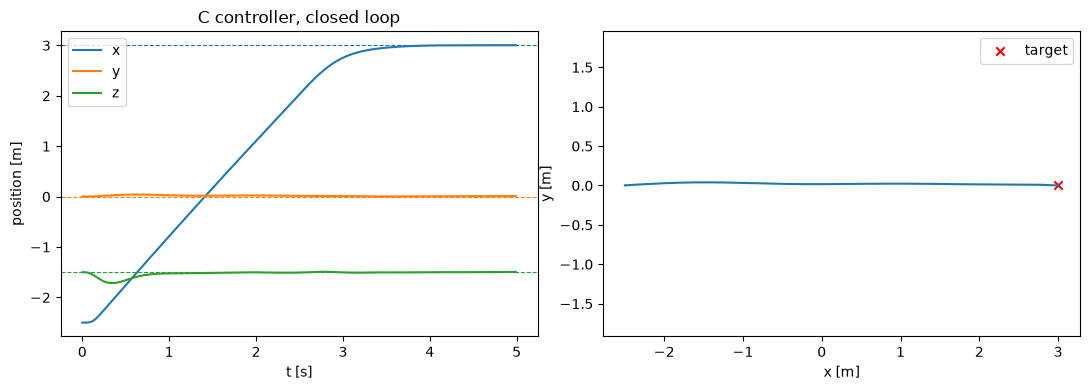

In [9]:

# Flown trajectory under the C controller
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
t = np.arange(len(traj)) * env.dt
for i, lbl in enumerate('xyz'):
    ax[0].plot(t, traj[:, i], label=lbl)
    ax[0].axhline(target[i], ls='--', lw=0.8, color=f'C{i}')
ax[0].set_xlabel('t [s]'); ax[0].set_ylabel('position [m]'); ax[0].legend(); ax[0].set_title('C controller, closed loop')
ax[1].plot(traj[:, 0], traj[:, 1])
ax[1].scatter(*target[:2], marker='x', color='r', label='target')
ax[1].set_xlabel('x [m]'); ax[1].set_ylabel('y [m]'); ax[1].axis('equal'); ax[1].legend()
plt.tight_layout(); plt.show()

## Integrating in indiflight

Size the two buffers off the header's `#define`s rather than a literal, so the same glue
code compiles against a quad or a hex export:

```c
#include "nn_controller.h"

static bool nn_was_active = false;

void nnControllerUpdate(timeUs_t currentTimeUs)
{
    bool nn_active = FLIGHT_MODE(NN_MODE);   // whatever gates the mode

    if (nn_active && !nn_was_active) {
        nn_reset();          // rising edge: clear waypoint index AND GRU hidden state
    }
    nn_was_active = nn_active;

    if (!nn_active) {
        return;              // never call nn_control() here: the GRU would integrate
    }                        // state for actions the drone never executed

    float world_state[NN_WORLD_STATE_DIM];   // 18 for the hex, 16 for the quad
    /* fill from the EKF / RPM telemetry, NED, rad, rad/s */
    float motor_cmds[NN_NUM_MOTORS];         // 6 for the hex, 4 for the quad
    nn_control(world_state, motor_cmds);
    /* write motor_cmds (0..1) to the motor outputs */
}
```

Checklist before flying:

- `motor_order[]` matches the indiflight mixer — all `NN_NUM_MOTORS` of them.
- The FC actually reports `NN_NUM_MOTORS` motor speeds; on the hex, `world_state[12..17]`
  must all be live, since a stale entry reads as a spun-down motor the GRU will fight.
- `MOTOR_OMEGA_SCALE` set to `2*M_PI/60` if the FC reports RPM rather than rad/s.
- The EKF's position/heading origin matches the training frame, or `WORLD_YAW_OFFSET` compensates.
- Arm with the drone roughly in the trained start box (x ≈ −3…−2, |y| ≤ 1, z ≈ −2…−1) — the
  GRU needs a few steps of in-distribution motion before its airframe estimate settles.